In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

df = pd.read_csv("kc_house_data.csv")

# Display first 5 rows


df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [9]:
# Check zero values in important columns

print("Zero values in bedrooms:", (df["bedrooms"] == 0).sum())
print("Zero values in bathrooms:", (df["bathrooms"] == 0).sum())
print("Zero values in sqft_living:", (df["sqft_living"] == 0).sum())
print("Zero values in sqft_lot:", (df["sqft_lot"] == 0).sum())

Zero values in bedrooms: 13
Zero values in bathrooms: 10
Zero values in sqft_living: 0
Zero values in sqft_lot: 0


In [11]:
df["bedrooms"] = df["bedrooms"].replace(0, np.nan)
df["bathrooms"] = df["bathrooms"].replace(0, np.nan)

In [13]:
print(df.isnull().sum())

id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64


In [15]:
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

In [17]:
print("Missing bedrooms:", df["bedrooms"].isnull().sum())
print("Missing bathrooms:", df["bathrooms"].isnull().sum())

Missing bedrooms: 0
Missing bathrooms: 0


In [19]:
# Convert date column into datetime

df["date"] = pd.to_datetime(df["date"])

# Extract year from sale date

df["sale_year"] = df["date"].dt.year

# Calculate age of house at the time of sale

df["house_age"] = df["sale_year"] - df["yr_built"]

# Calculate years since renovation

df["years_since_renovation"] = np.where(
    df["yr_renovated"] > 0,
    df["sale_year"] - df["yr_renovated"],
    np.nan
)

# Display results

df[["date", "sale_year", "yr_built", "yr_renovated",
    "house_age", "years_since_renovation"]].head()

,date,sale_year,yr_built,yr_renovated,house_age,years_since_renovation
0,2014-10-13,2014,1955,0,59,NaN
1,2014-12-09,2014,1951,1991,63,23.0
2,2015-02-25,2015,1933,0,82,NaN
3,2014-12-09,2014,1965,0,49,NaN
4,2015-02-18,2015,1987,0,28,NaN


In [21]:
# Price per square foot of living area

df["price_per_sqft_living"] = df["price"] / df["sqft_living"]

# Price per square foot of total lot size

df["price_per_sqft_lot"] = df["price"] / df["sqft_lot"]

# Display results

df[["price", "sqft_living", "sqft_lot",
    "price_per_sqft_living",
    "price_per_sqft_lot"]].head()

,price,sqft_living,sqft_lot,price_per_sqft_living,price_per_sqft_lot
0,221900.0,1180,5650,188.050847,39.274336
1,538000.0,2570,7242,209.338521,74.288870
2,180000.0,770,10000,233.766234,18.000000
3,604000.0,1960,5000,308.163265,120.800000
4,510000.0,1680,8080,303.571429,63.118812


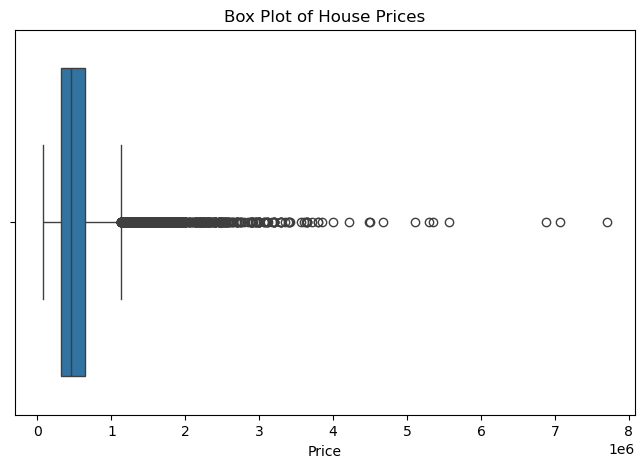

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price"])

plt.title("Box Plot of House Prices")
plt.xlabel("Price")

plt.show()

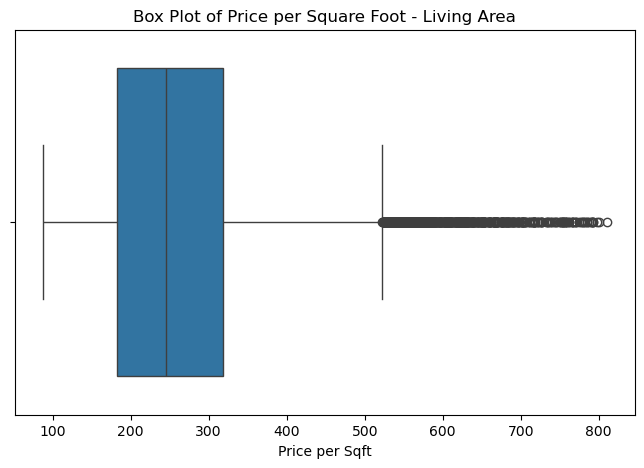

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price_per_sqft_living"])

plt.title("Box Plot of Price per Square Foot - Living Area")
plt.xlabel("Price per Sqft")

plt.show()

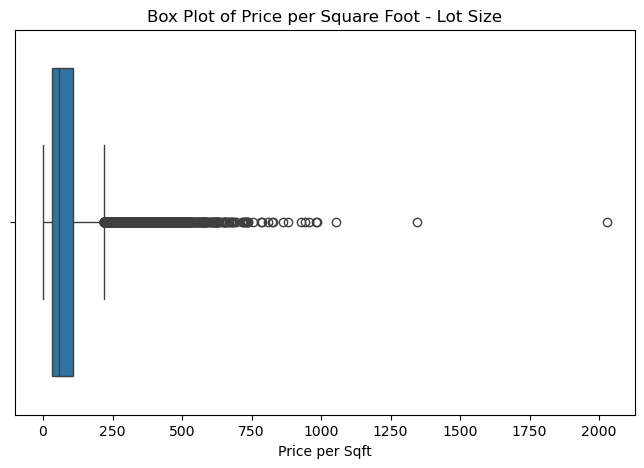

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price_per_sqft_lot"])

plt.title("Box Plot of Price per Square Foot - Lot Size")
plt.xlabel("Price per Sqft")

plt.show()

In [29]:
# Calculate Q1 and Q3

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Calculate lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 321950.0
Q3: 645000.0
IQR: 323050.0
Lower Bound: -162625.0
Upper Bound: 1129575.0


In [ ]:
# Identify price outliers

price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Number of Price Outliers:", len(price_outliers))

# Display outliers

price_outliers[["id", "price", "bedrooms",
                 "bathrooms", "sqft_living"]].head(20)